# Flow Matching: Unconstrained Optimization

Find stationary points (minima, maxima) by conditioning on $f'(x) = 0$.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.11 (main, Jun 12 2025, 12:22:42) [Clang 20.1.4 ]
Platform: macOS-15.6.1-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.7


sklearn              1.6.1


torch                2.7.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 08:15:25
Initial memory usage: 330.31 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Problem Setup

For $f(x) = x^4 - 4x^2 + x + 3$, find stationary points where $f'(x) = 0$.

The derivative is $f'(x) = 4x^3 - 8x + 1$.

The approach:
1. Generate training data: pairs of $(x, f'(x))$
2. Train flow matching to generate $x$ conditioned on $f'(x)$
3. Sample by conditioning on $f'(x) = 0$

In [3]:
# Generate data with derivatives - more points and oversample near stationary points
x_base = np.linspace(-2.25, 2, 1000)
y_base = x_base**4 - 4*x_base**2 + x_base + 3
y_prime_base = 4*x_base**3 - 8*x_base + 1

# True stationary points
stationary = np.roots([4, 0, -8, 1])
print(f"Stationary points: {stationary}")

# Oversample near stationary points (where y' is close to 0)
x_near_stat = []
for s in stationary:
    x_near_stat.append(np.linspace(s - 0.3, s + 0.3, 200))
x_near_stat = np.concatenate(x_near_stat)
y_prime_near_stat = 4*x_near_stat**3 - 8*x_near_stat + 1

# Combine base and oversampled data
x = np.concatenate([x_base, x_near_stat])
y_prime = np.concatenate([y_prime_base, y_prime_near_stat])

print(f"Total data points: {len(x)}")
print(f"Data points near stationary points: {len(x_near_stat)}")

Stationary points: [-1.4729976   1.34699741  0.12600019]
Total data points: 1600
Data points near stationary points: 600


In [4]:
# Train flow matching: generate x conditioned on y'
# Use larger model and more epochs
x_data = x.reshape(-1, 1)
c_data = y_prime.reshape(-1, 1)

fm_opt = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses = fm_opt.fit(x_data, c_data, epochs=1000, batch_size=128)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

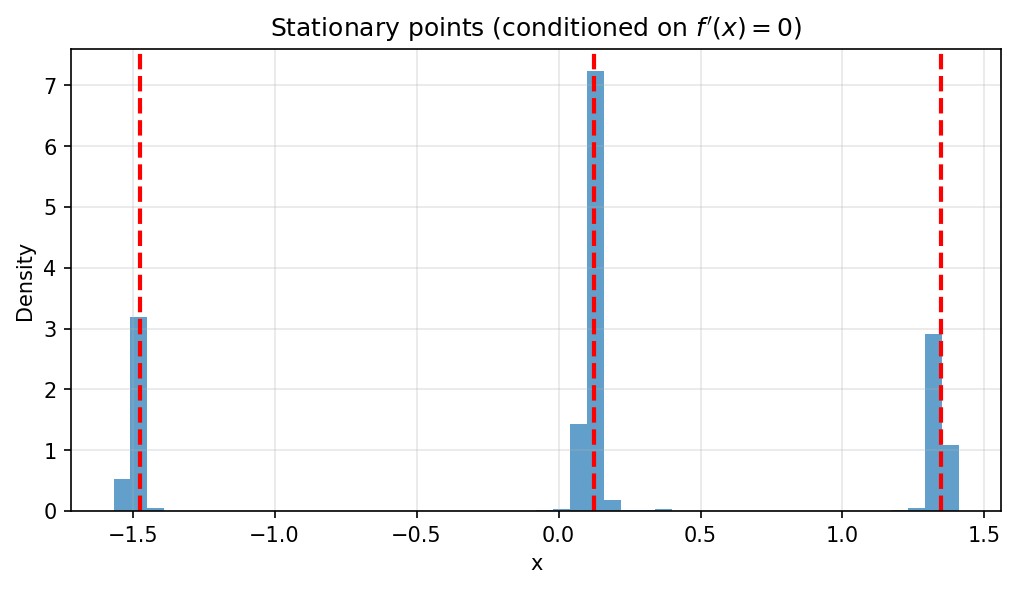

Cluster statistics:
  0:  -1.4927 +/- 0.0175 (n=224)
  1:   0.1174 +/- 0.0264 (n=534)
  2:   1.3419 +/- 0.0192 (n=242)


In [5]:
# Sample stationary points by conditioning on y'=0
# Use more integration steps
samples = fm_opt.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

plt.figure(figsize=(8, 4))
plt.hist(samples[:, 0], bins=50, density=True, alpha=0.7)
for s in stationary:
    plt.axvline(s, color='r', ls='--', lw=2)
plt.xlabel('x')
plt.ylabel('Density')
plt.title("Stationary points (conditioned on $f'(x)=0$)")
plt.grid(True, alpha=0.3)
plt.show()

print("Cluster statistics:")
cluster_stats(samples, eps=0.3)

## Distinguishing Minima from Maxima

We can use the sign of the second derivative to distinguish:
- $f''(x) > 0$: minimum
- $f''(x) < 0$: maximum

In [6]:
# Distinguish minima from maxima using second derivative sign
y_double_prime_sign = np.where((12 * x**2 - 8) > 0, 1.0, -1.0)

# Condition on both y' and sign(y'')
c_data = np.column_stack([y_prime, y_double_prime_sign])

fm_opt2 = ConditionalFlowMatching(x_dim=1, c_dim=2, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses = fm_opt2.fit(x_data, c_data, epochs=1000, batch_size=128)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
# Find maximum: y'=0, y''<0 (sign=-1)
samples_max = fm_opt2.sample(c_values=[[0.0, -1.0]], n_samples=500, n_steps=100)

print("Maximum (y'=0, y''<0):")
cluster_stats(samples_max, eps=0.3)

# Find minima: y'=0, y''>0 (sign=+1)
samples_min = fm_opt2.sample(c_values=[[0.0, 1.0]], n_samples=500, n_steps=100)

print("\nMinima (y'=0, y''>0):")
cluster_stats(samples_min, eps=0.3)

Maximum (y'=0, y''<0):
  0:   0.1265 +/- 0.0094 (n=500)

Minima (y'=0, y''>0):
 -1:   0.2275 +/- 0.0000 (n=1)
  0:  -1.4758 +/- 0.0209 (n=215)
  1:   1.3436 +/- 0.0447 (n=284)


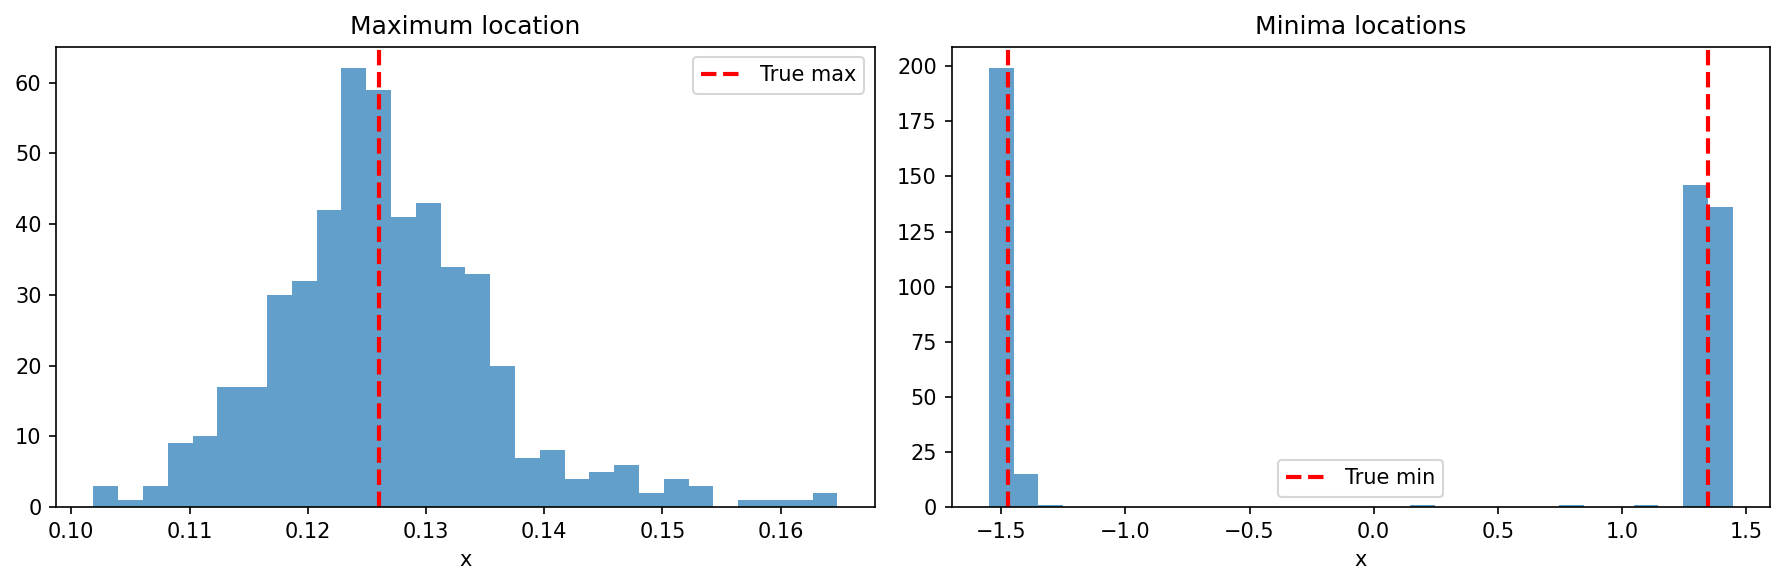

In [8]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(samples_max[:, 0], bins=30, alpha=0.7)
axes[0].axvline(0.126, color='r', ls='--', lw=2, label='True max')
axes[0].set_xlabel('x')
axes[0].set_title('Maximum location')
axes[0].legend()

axes[1].hist(samples_min[:, 0], bins=30, alpha=0.7)
axes[1].axvline(-1.473, color='r', ls='--', lw=2, label='True min')
axes[1].axvline(1.347, color='r', ls='--', lw=2)
axes[1].set_xlabel('x')
axes[1].set_title('Minima locations')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Chemical Engineering Example: Maximizing Intermediate Product

Consider consecutive reactions A → B → C in a batch reactor, where B is the desired product.

**Problem:** Find optimal residence time τ to maximize concentration of intermediate B.

For first-order consecutive reactions with rate constants k₁ and k₂:

$$C_B(\tau) = \frac{C_{A0} k_1}{k_2 - k_1} \left(e^{-k_1\tau} - e^{-k_2\tau}\right)$$

$$\frac{dC_B}{d\tau} = C_{A0} k_1 \frac{k_2 e^{-k_2\tau} - k_1 e^{-k_1\tau}}{k_2 - k_1}$$

**Analytical optimum:** $\tau^* = \frac{\ln(k_1/k_2)}{k_1 - k_2}$

Consecutive Reactions: A -> B -> C
Rate constants: k1=0.5 min^-1, k2=0.2 min^-1

Analytical optimum:
  Optimal residence time: τ* = 3.054 min
  Maximum CB concentration: 0.5429 mol/L

Total data points: 1500
Data points near optimum: 500


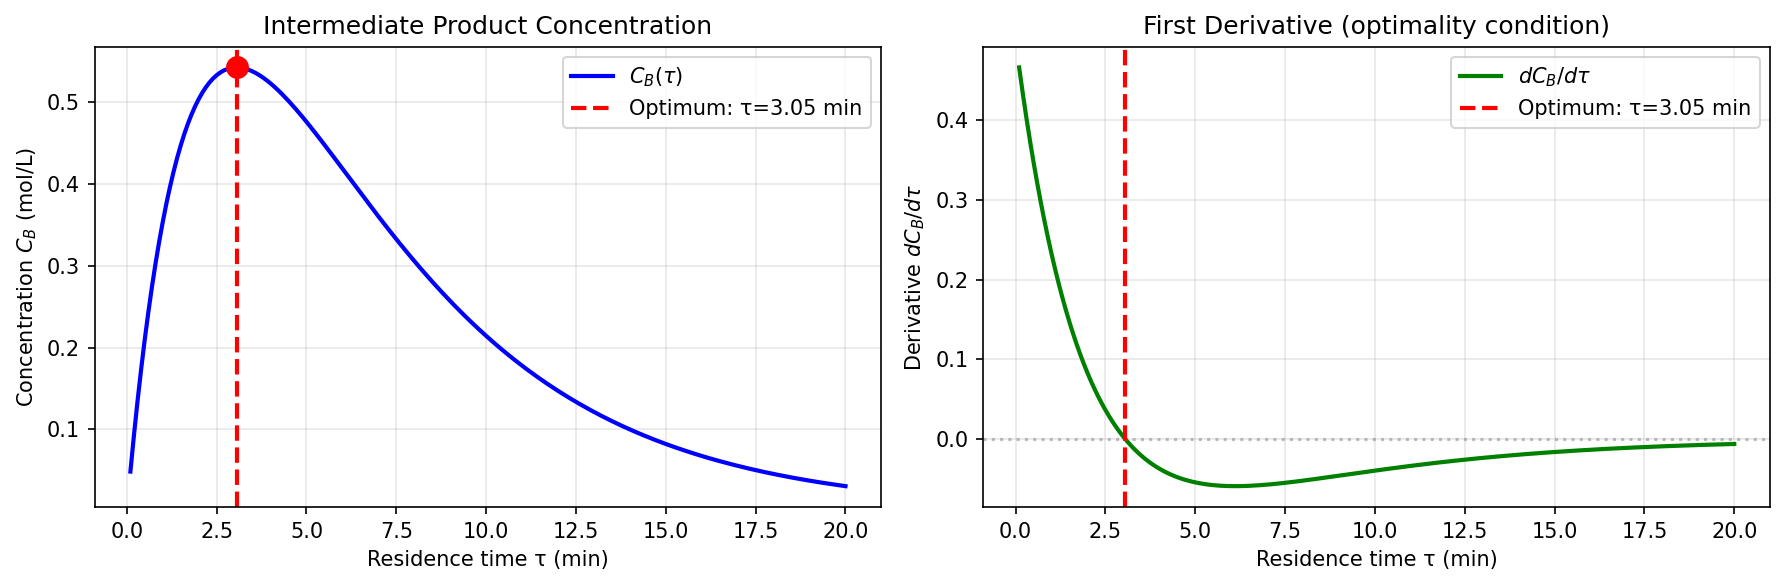

In [9]:
# Consecutive reactions: A -> B -> C
# Parameters
k1 = 0.5  # min^-1 (A -> B)
k2 = 0.2  # min^-1 (B -> C)
CA0 = 1.0  # mol/L (initial concentration of A)

# Generate data - oversample near optimum
tau_base = np.linspace(0.1, 20, 1000)  # residence time (min)

# Analytical optimum
tau_opt_analytical = np.log(k1 / k2) / (k1 - k2)
CB_max_analytical = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_opt_analytical) - np.exp(-k2 * tau_opt_analytical))

print(f"Consecutive Reactions: A -> B -> C")
print(f"Rate constants: k1={k1} min^-1, k2={k2} min^-1")
print(f"\nAnalytical optimum:")
print(f"  Optimal residence time: τ* = {tau_opt_analytical:.3f} min")
print(f"  Maximum CB concentration: {CB_max_analytical:.4f} mol/L")

# Oversample near optimum
tau_near_opt = np.linspace(tau_opt_analytical - 2, tau_opt_analytical + 2, 500)
tau = np.concatenate([tau_base, tau_near_opt])

# Concentration of B
CB = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau) - np.exp(-k2 * tau))

# Derivative dCB/dtau
dCB_dtau = CA0 * k1 * (k2 * np.exp(-k2 * tau) - k1 * np.exp(-k1 * tau)) / (k2 - k1)

print(f"\nTotal data points: {len(tau)}")
print(f"Data points near optimum: {len(tau_near_opt)}")

# Visualize
tau_plot = np.linspace(0.1, 20, 200)
CB_plot = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_plot) - np.exp(-k2 * tau_plot))
dCB_dtau_plot = CA0 * k1 * (k2 * np.exp(-k2 * tau_plot) - k1 * np.exp(-k1 * tau_plot)) / (k2 - k1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: CB vs tau
axes[0].plot(tau_plot, CB_plot, 'b-', lw=2, label='$C_B(\\tau)$')
axes[0].axvline(tau_opt_analytical, color='r', ls='--', lw=2, label=f'Optimum: τ={tau_opt_analytical:.2f} min')
axes[0].plot(tau_opt_analytical, CB_max_analytical, 'ro', ms=10, zorder=5)
axes[0].set_xlabel('Residence time τ (min)')
axes[0].set_ylabel('Concentration $C_B$ (mol/L)')
axes[0].set_title('Intermediate Product Concentration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Derivative
axes[1].plot(tau_plot, dCB_dtau_plot, 'g-', lw=2, label="$dC_B/d\\tau$")
axes[1].axhline(0, color='gray', ls=':', alpha=0.5)
axes[1].axvline(tau_opt_analytical, color='r', ls='--', lw=2, label=f'Optimum: τ={tau_opt_analytical:.2f} min')
axes[1].set_xlabel('Residence time τ (min)')
axes[1].set_ylabel('Derivative $dC_B/d\\tau$')
axes[1].set_title('First Derivative (optimality condition)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Train Flow Matching: generate τ conditioned on dCB/dτ
x_data_rxn = tau.reshape(-1, 1)
c_data_rxn = dCB_dtau.reshape(-1, 1)

fm_rxn = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses_rxn = fm_rxn.fit(x_data_rxn, c_data_rxn, epochs=1000, batch_size=128, verbose=True)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Flow Matching Optimization Results:
  Analytical optimum: τ* = 3.054 min
  FM mean: 3.042 ± 0.071 min
  FM median: 3.039 min

Cluster statistics:
 -1:   4.1234 +/- 0.3277 (n=2)
  0:   3.0397 +/- 0.0499 (n=998)


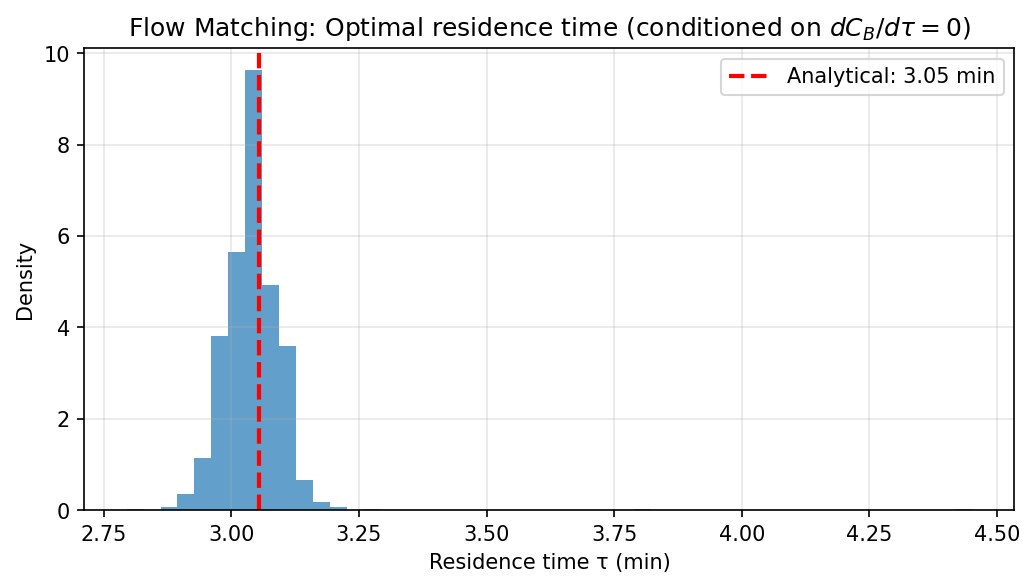

In [11]:
# Find optimum by conditioning on dCB/dτ = 0
samples_rxn = fm_rxn.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

print(f"Flow Matching Optimization Results:")
print(f"  Analytical optimum: τ* = {tau_opt_analytical:.3f} min")
print(f"  FM mean: {samples_rxn[:, 0].mean():.3f} ± {samples_rxn[:, 0].std():.3f} min")
print(f"  FM median: {np.median(samples_rxn[:, 0]):.3f} min")

print(f"\nCluster statistics:")
cluster_stats(samples_rxn[:, 0], eps=0.5)

# Visualize
plt.figure(figsize=(8, 4))
plt.hist(samples_rxn[:, 0], bins=50, alpha=0.7, density=True)
plt.axvline(tau_opt_analytical, c='r', ls='--', lw=2, label=f'Analytical: {tau_opt_analytical:.2f} min')
plt.xlabel('Residence time τ (min)')
plt.ylabel('Density')
plt.title('Flow Matching: Optimal residence time (conditioned on $dC_B/d\\tau = 0$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Summary: Consecutive Reactions Optimization

Flow Matching successfully identifies the optimal residence time to maximize intermediate product B concentration by conditioning on the derivative being zero. The results closely match the analytical optimum.

**Key insights:**
- **Too short residence time:** Insufficient conversion of A to B
- **Too long residence time:** Excessive conversion of B to C
- **Optimal point:** Balances formation and consumption of B

The model learns the relationship τ → dC_B/dτ during training, then inverts it at inference time by conditioning on dC_B/dτ = 0. This demonstrates the power of generative models for solving optimization problems through conditional sampling.

In [12]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 08:15:25
End time:        2025-12-18 08:16:15
Elapsed time:    49.70 seconds (0.83 minutes)
----------------------------------------------------------------------
Initial memory:  330.31 MB
Final memory:    514.36 MB
Memory change:   +184.05 MB
